In [2]:
from __future__ import division, print_function
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table, vstack, hstack
import fitsio
import sys, os, glob, time, warnings, gc
# import healpy as hp

from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import LogNorm

sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/Users/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [3]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

# Apply MEDIUM and WISE masks and require NOBS>=2

In [4]:
maskbits = [1, 8, 11, 12, 13]
min_nobs = 2

In [3]:
cat0 = Table(fitsio.read('/Volumes/Samsung T5/tmp/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_basic.fits'))
cat = Table(fitsio.read('/Volumes/Samsung T5/tmp/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_photom.fits'))
cat1 = Table(fitsio.read('/Volumes/Samsung T5/tmp/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_more_1.fits', columns=['GAIA_PHOT_G_MEAN_MAG', 'Z_PHOT_MEDIAN', 'Z_PHOT_U68', 'Z_PHOT_L68']))
cat = hstack([cat0, cat, cat1], join_type='exact')
print(len(cat))

31485458


In [5]:
mask = cat['DEC']>-30
cat = cat[mask]
print(len(cat))

mask_remove = (cat['GAIA_PHOT_G_MEAN_MAG']!=0) & (cat['GAIA_PHOT_G_MEAN_MAG']<18)
cat = cat[~mask_remove]
print(len(cat))

mask = (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
cat = cat[mask]
print(len(cat))

24978592
24967605
23490901


In [6]:
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))
cat = cat[mask_clean]
print(len(cat))

0.08219944394640291
21559962


In [7]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gmag = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
    rmag = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
    zmag = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
    w1mag = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    w2mag = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
    rfibermag = 22.5 - 2.5*np.log10(cat['FIBERFLUX_R']/cat['MW_TRANSMISSION_R'])
    zfibermag = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']/cat['MW_TRANSMISSION_Z'])

    gmag[~np.isfinite(gmag)] = 100.
    rmag[~np.isfinite(rmag)] = 100.
    zmag[~np.isfinite(zmag)] = 100.
    w1mag[~np.isfinite(w1mag)] = 100.
    w2mag[~np.isfinite(w2mag)] = 100.
    rfibermag[~np.isfinite(rfibermag)] = 100.
    zfibermag[~np.isfinite(zfibermag)] = 100.
    
    gflux_ivar = cat['FLUX_IVAR_R']
    
gaia_g = cat['GAIA_PHOT_G_MEAN_MAG']

In [8]:
cat.add_columns([gmag, rmag, zmag, w1mag, w2mag, zfibermag, rfibermag], names=['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'zfibermag', 'rfibermag'])

z_phot = cat['Z_PHOT_MEDIAN']
# Perturb the photo-z's by the estimated errors
cat['z_phot_1_sigma'] = (cat['Z_PHOT_U68']-cat['Z_PHOT_L68'])/2
np.random.seed(123)
z_phot_perturb = cat['Z_PHOT_MEDIAN'] + np.random.randn(len(cat)) * cat['z_phot_1_sigma']

In [9]:
randoms_path = '/Volumes/Samsung T5/tmp/dr9.0/0.49.0/dr9_randoms_south_0.49.0-1-0.fits'
randoms_columns = ['RA', 'DEC',  'NOBS_G', 'NOBS_R', 'NOBS_Z', 'MASKBITS']

randoms = Table(fitsio.read(randoms_path, columns=randoms_columns))
print(len(randoms))
randoms_density = fitsio.read_header(randoms_path, ext=1)['DENSITY']
print(randoms_density)

36643785
2500


In [10]:
mask = (randoms['NOBS_G']>=min_nobs) & (randoms['NOBS_R']>=min_nobs) & (randoms['NOBS_Z']>=min_nobs)
randoms = randoms[mask]
print(len(randoms))

mask_clean = np.ones(len(randoms), dtype=bool)
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))
randoms = randoms[mask_clean]
print(len(randoms))

34761148
0.06519632205472616
32494849


In [11]:
mask = randoms['DEC']>-30
randoms = randoms[mask]
print(len(randoms))

25272536


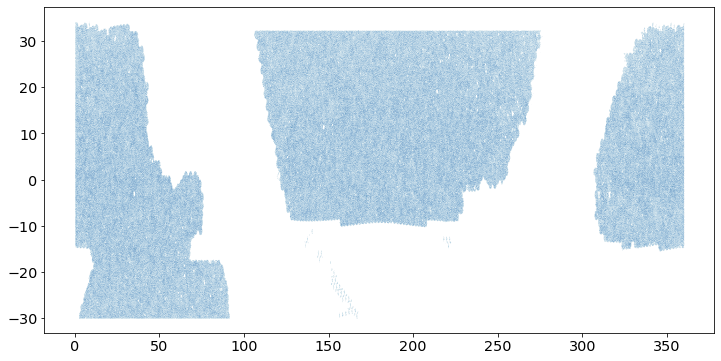

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(cat['RA'][::10], cat['DEC'][::10], '.', ms=0.1, alpha=0.1)
plt.show()

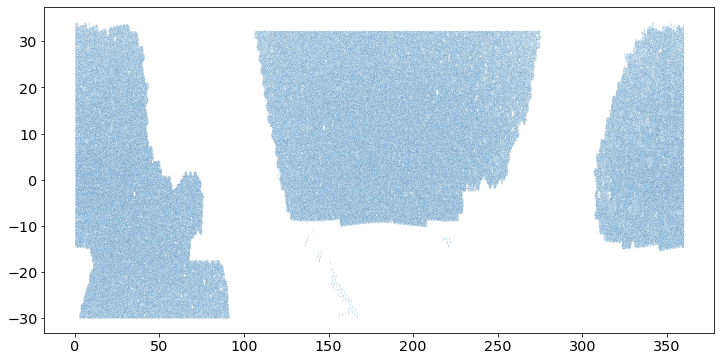

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(randoms['RA'][::10], randoms['DEC'][::10], '.', ms=0.1, alpha=0.1)
plt.show()

In [14]:
area_clean = len(randoms)/randoms_density
print('area = {:.1f}'.format(area_clean))

area = 10109.0


In [15]:
downsample_factor = 1

def print_summary(mask):
    print('target density: {:.1f} per sq deg'.format(np.sum(mask)/area_clean*downsample_factor))

In [16]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'

In [24]:
# Changelog:
# - Add GAIA_G>18 cut
# - Revised low-z (g-r vs r-W1) cuts from Jeff (same north and south cuts)
# - Shift the low-z cut intercept by 0.1 in the north (decreasing the density), to account for the north vs south difference
# - Shift the sliding IR cut intercept by 0.05*1.8 (increasing the density), to match the optical target density

#################### Updated optical selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.83) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.80) * 0.19       # low-z sliding optical cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_opt_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.79) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.76) * 0.19       # low-z sliding optical cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_opt_north = lrg_mask.copy()

lrg_opt = lrg_opt_south | lrg_opt_north
print(np.sum(lrg_opt))

#################### Updated IR selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.27) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.37) * 1.  # low-z sliding IR cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_ir_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.23) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut

mask_lowz = ((gmag-rmag) > 0.3*(rmag-w1mag)+0.9 )  & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_ir_north = lrg_mask.copy()

lrg_ir = lrg_ir_south | lrg_ir_north
print(np.sum(lrg_ir))

print('Optical:', np.sum(lrg_opt))
print_summary(lrg_opt)

print('IR:', np.sum(lrg_ir))
print_summary(lrg_ir)

6204607
6212857
Optical: 6204607
target density: 613.8 per sq deg
IR: 6212857
target density: 614.6 per sq deg


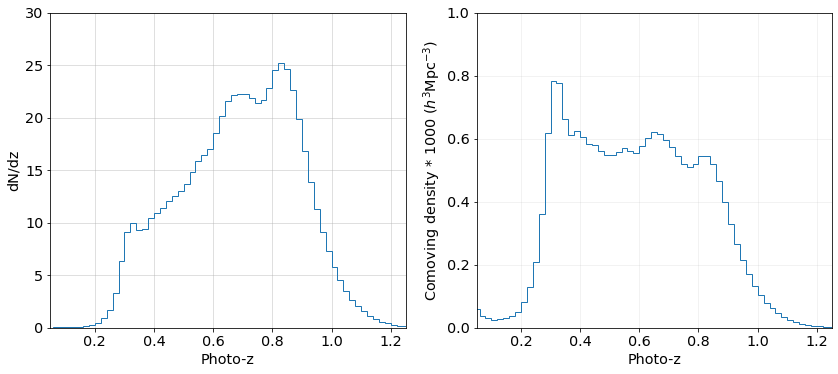

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(0.04, 1.44, 0.02)
axes[0].hist(z_phot_perturb[lrg_opt], bins=bins,
             weights=np.ones(int(np.sum(lrg_opt)))/area_clean*downsample_factor, histtype='step')
axes[0].set_xlabel('Photo-z')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(0.05, 1.25)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(z_phot_perturb[lrg_opt], area=area_clean/downsample_factor, zmin=0.04, zmax=1.44, dz=0.02, axis=[0.05, 1.25, 0, 1.])

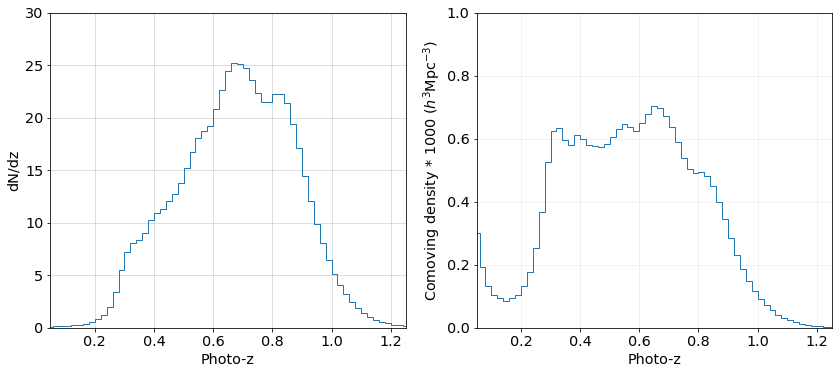

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(0.04, 1.44, 0.02)
axes[0].hist(z_phot_perturb[lrg_ir], bins=bins,
             weights=np.ones(int(np.sum(lrg_ir)))/area_clean*downsample_factor, histtype='step')
axes[0].set_xlabel('Photo-z')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(0.05, 1.25)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(z_phot_perturb[lrg_ir], area=area_clean/downsample_factor, zmin=0.04, zmax=1.44, dz=0.02, axis=[0.05, 1.25, 0, 1.])

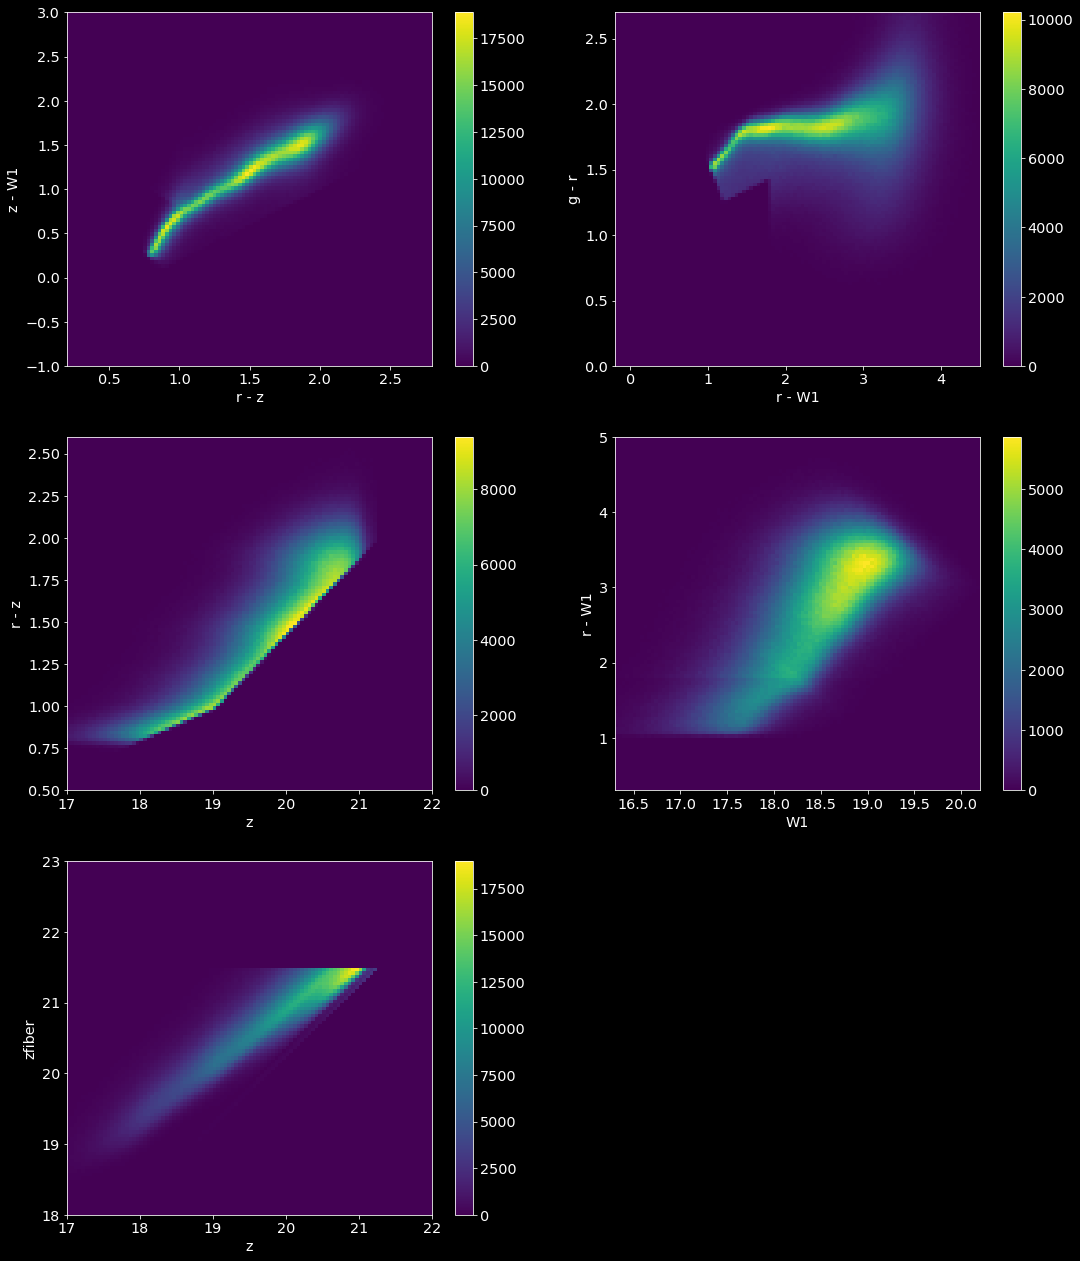

In [31]:
lrg_plot.density_plot_3x2_new(cat[lrg_opt], lognorm=False)

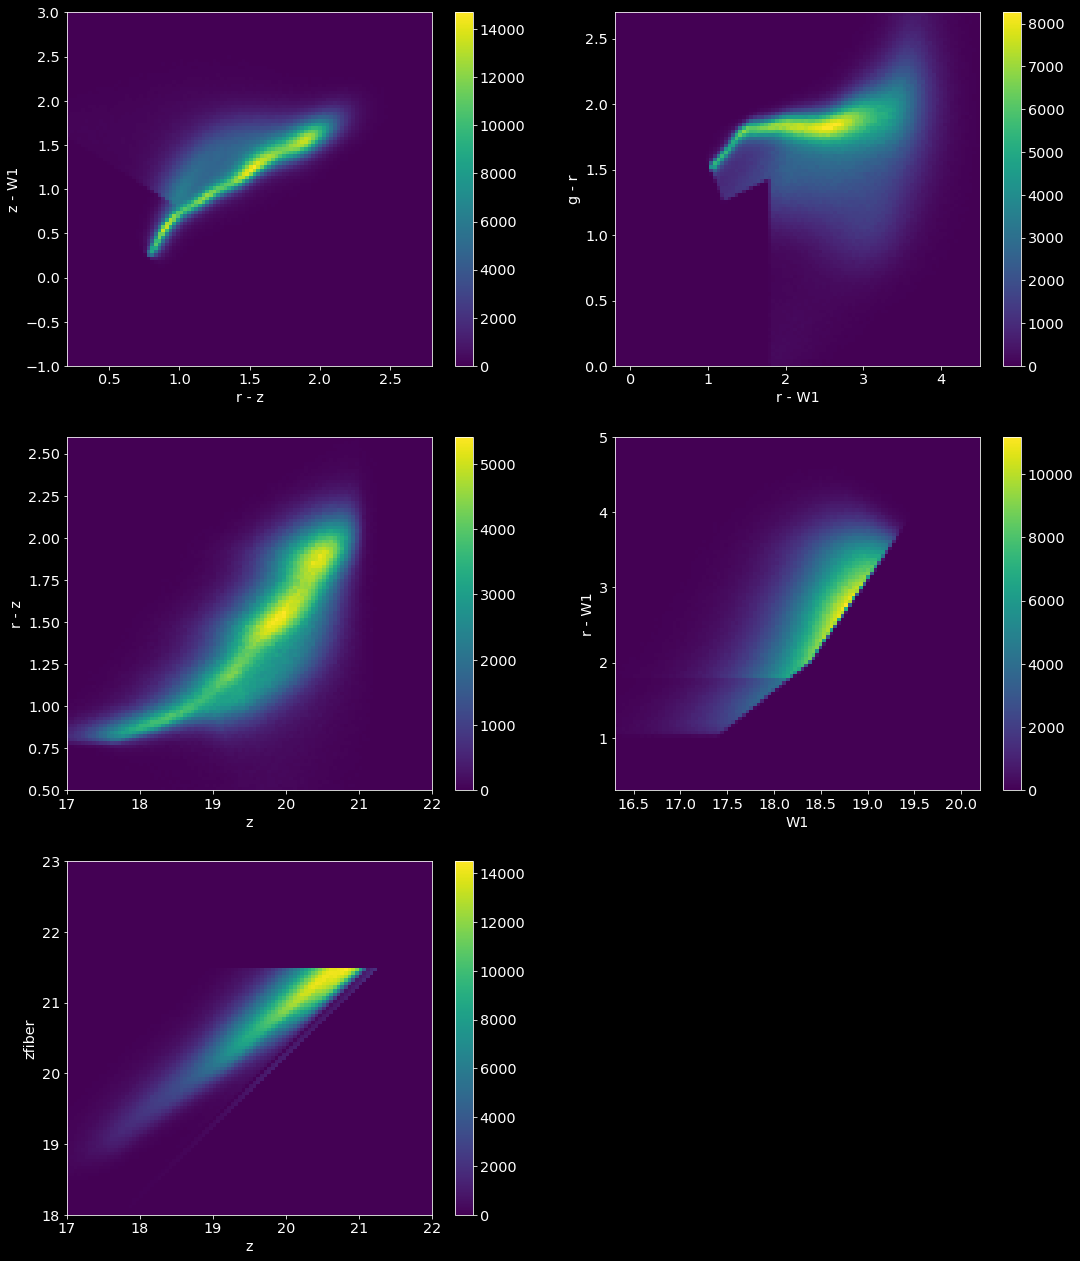

In [30]:
lrg_plot.density_plot_3x2_new(cat[lrg_ir], lognorm=False)

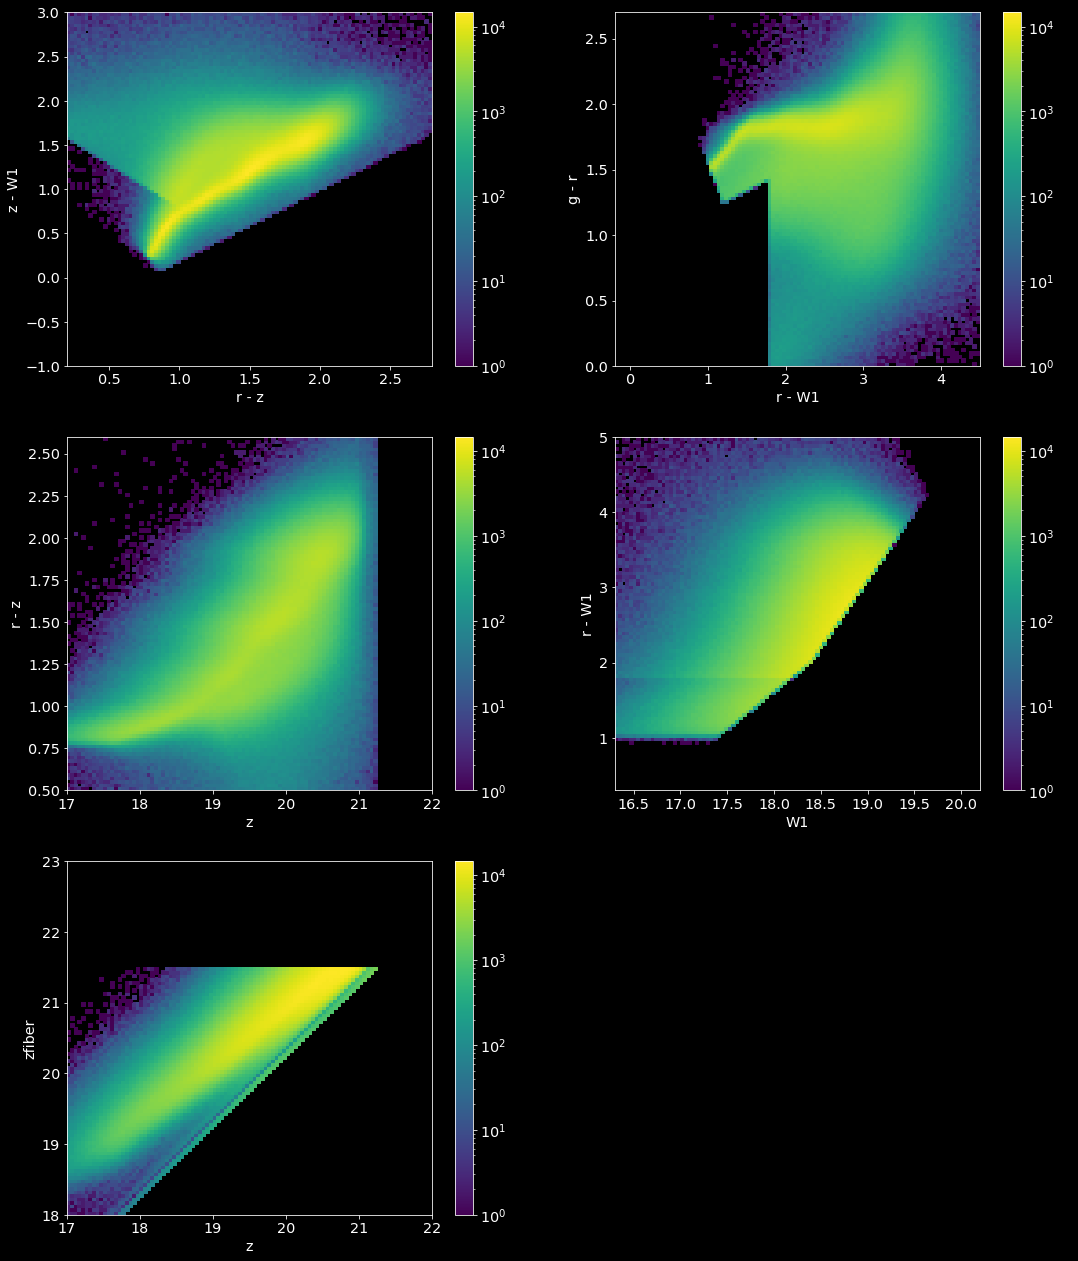

In [29]:
lrg_plot.density_plot_3x2_new(cat[lrg_ir])

--------
# Blue (g-r) galaxies in the IR sample

Objects that are red in z-W1 but blue in g-r

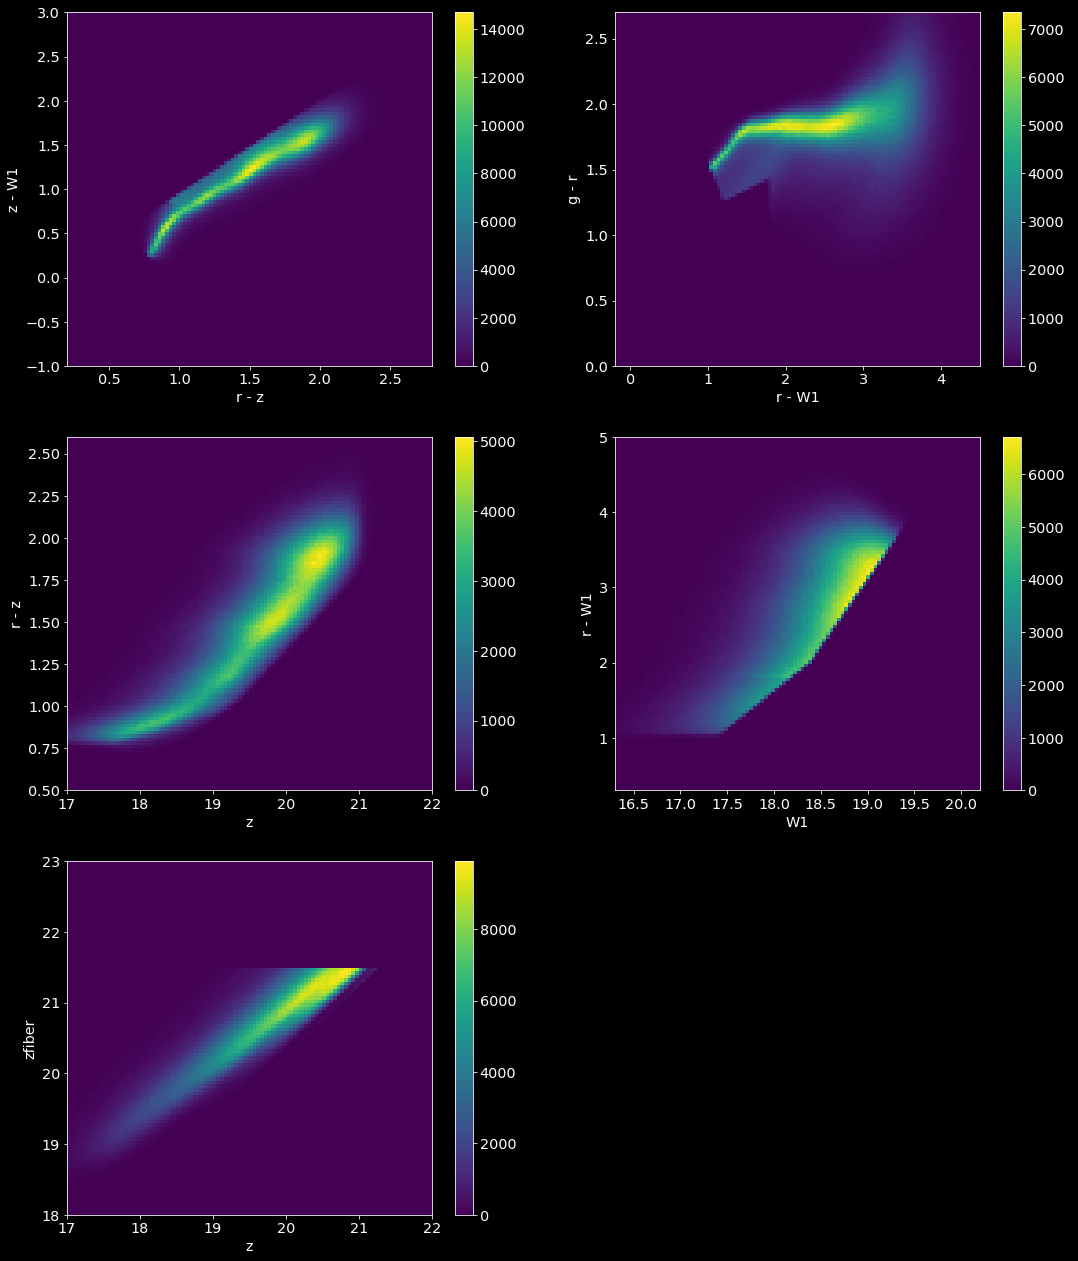

In [51]:
mask1 = (zmag - w1mag > 1.05 * (rmag-zmag) - 0.1)
mask = lrg_ir & (~mask1)
lrg_plot.density_plot_3x2_new(cat[mask], lognorm=False)

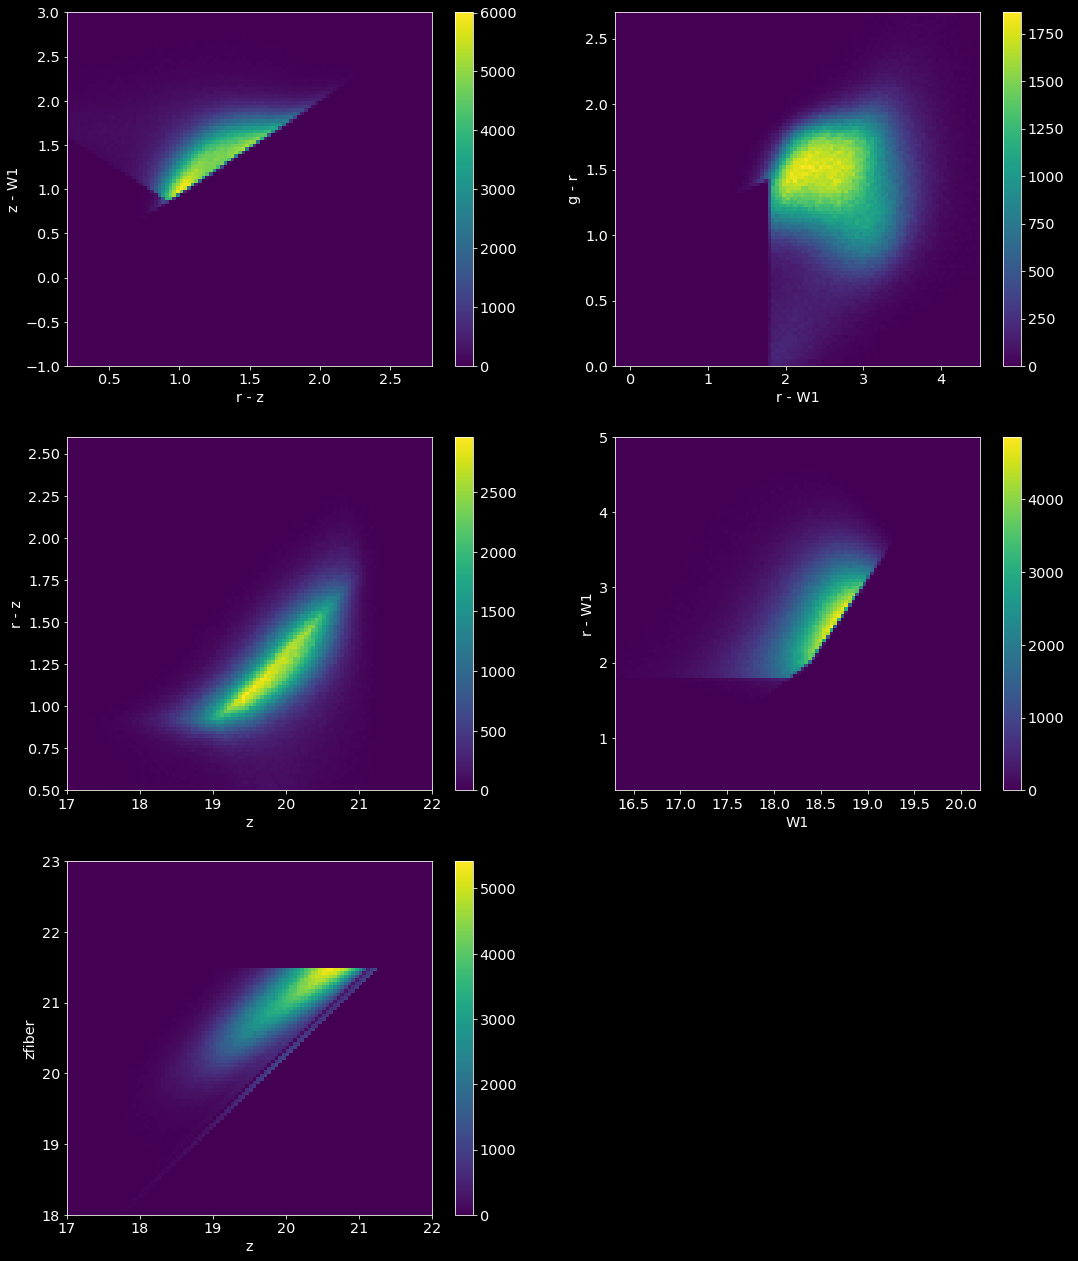

In [52]:
mask1 = (zmag - w1mag > 1.05 * (rmag-zmag) - 0.1)
mask = lrg_ir & mask1
lrg_plot.density_plot_3x2_new(cat[mask], lognorm=False)

In [60]:
mask1 = (zmag - w1mag > 1.05 * (rmag-zmag) - 0.08)
mask = lrg_ir & mask1
print(np.sum(mask), np.sum(mask)/np.sum(lrg_ir))

1728738 0.27825169644174974


In [59]:
t = Table()
t['type'], t['count'] = np.unique(cat['MORPHTYPE'][lrg_ir & (~mask1)], return_counts=True)
t['frac (%)'] = t['count']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

type,count,frac (%)
str4,int64,float64
PSF,15310,0.8
EXP,187856,10.3
SER,859853,47.2
REX,912693,50.1
DEV,2415418,132.6


In [58]:
t = Table()
t['type'], t['count'] = np.unique(cat['MORPHTYPE'][mask], return_counts=True)
t['frac (%)'] = t['count']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

type,count,frac (%)
str4,int64,float64
PSF,74618,4.1
SER,289595,15.9
DEV,429496,23.6
EXP,453713,24.9
REX,574305,31.5


In [54]:
idx = np.where(mask)[0]
print(len(idx))
if len(idx)>200:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/Users/rongpu/Downloads/visual_inspection.txt', format='ascii.no_header', overwrite=True)

1821727


-------
# IR excess tests

In [61]:
lrg1 = lrg_ir.copy()
lrg1 &= (zmag - w1mag < 1.05 * (rmag-zmag) - 0.08) | (rmag - zmag > 1.1)
print(np.sum(lrg1)/np.sum(lrg_ir))

0.8976345343213276


In [62]:
lrg1 = lrg_ir.copy()
lrg1 &= (zmag - w1mag < 1.05 * (rmag-zmag) - 0.08) | (rmag - w1mag > 2.25)
print(np.sum(lrg1)/np.sum(lrg_ir))

0.9416815806319058


In [63]:
lrg1 = lrg_ir.copy()
lrg1 &= (zmag - w1mag < 1.05 * (rmag-zmag) - 0.08)
print(np.sum(lrg1)/np.sum(lrg_ir))

0.7217481426017048


In [64]:
lrg1 = lrg_ir.copy()
lrg1 &= (zmag - w1mag < 1.05 * (rmag-zmag) - 0.08) | (rmag - zmag > 0.95)
print(np.sum(lrg1)/np.sum(lrg_ir))

0.9520724523355358


In [65]:
south = True

In [82]:
lrg = (zfibermag < 21.5)                   # faint limit

lrg &= (gaia_g == 0) | (gaia_g > 18)  # remove bright GAIA sources

if south:
    lrg &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6    # non-stellar cut.
    lrg &= (
        (((gmag - rmag) > 0.3 * (rmag - w1mag)+0.9) & ((gmag - rmag) > -1.55*(rmag - w1mag)+3.13))
        | (rmag - w1mag > 1.8)                       # low-z cut.
    )
    lrg &= rmag - w1mag > (w1mag - 17.27) * 1.8      # double sliding cut 1.
    lrg &= rmag - w1mag > (w1mag - 16.37) * 1.       # double sliding cut 2.
else:
    lrg &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6   # non-stellar cut.
    lrg &= (
        (((gmag - rmag) > 0.3 * (rmag - w1mag)+0.9) & ((gmag - rmag) > -1.55*(rmag - w1mag)+3.23))
        | (rmag - w1mag > 1.8)                       # low-z cut.
    )
    lrg &= rmag - w1mag > (w1mag - 17.23) * 1.8      # double sliding cut 1.
    lrg &= rmag - w1mag > (w1mag - 16.33) * 1.       # double sliding cut 2.

In [83]:
np.sum(lrg)

6212857

In [84]:
np.sum(lrg_ir)

6212857

In [85]:
np.all(lrg==lrg_ir)

True